In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.datasets import make_classification

In [27]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [28]:
X

array([[ 1.56348861,  0.42236754],
       [-0.41215947,  1.868307  ],
       [-0.46522299, -1.90660776],
       ...,
       [-2.18264424, -0.82646055],
       [ 0.67857322, -2.24203186],
       [ 0.2604098 ,  0.72970342]])

In [29]:
y


array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,

In [30]:
pd.DataFrame(X)[0]

,0
0,1.563489
1,-0.412159
2,-0.465223
3,-0.457554
4,0.506662
...,...
995,-0.379749
996,1.112442
997,-2.182644
998,0.678573


<Axes: xlabel='feature_0', ylabel='feature_1'>

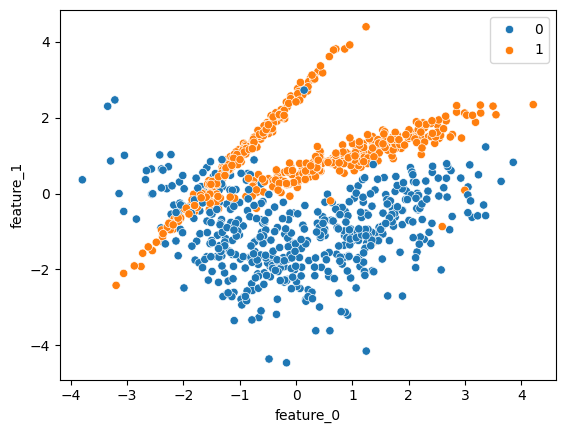

In [31]:
df = pd.DataFrame(X, columns=['feature_0', 'feature_1'])
sns.scatterplot(x='feature_0', y='feature_1', hue=y, data=df)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=43)

In [34]:
from sklearn.svm import SVC

In [35]:
svc = SVC(kernel='linear')

In [36]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [37]:
y_pred = svc.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_pred,y_test)

0.89

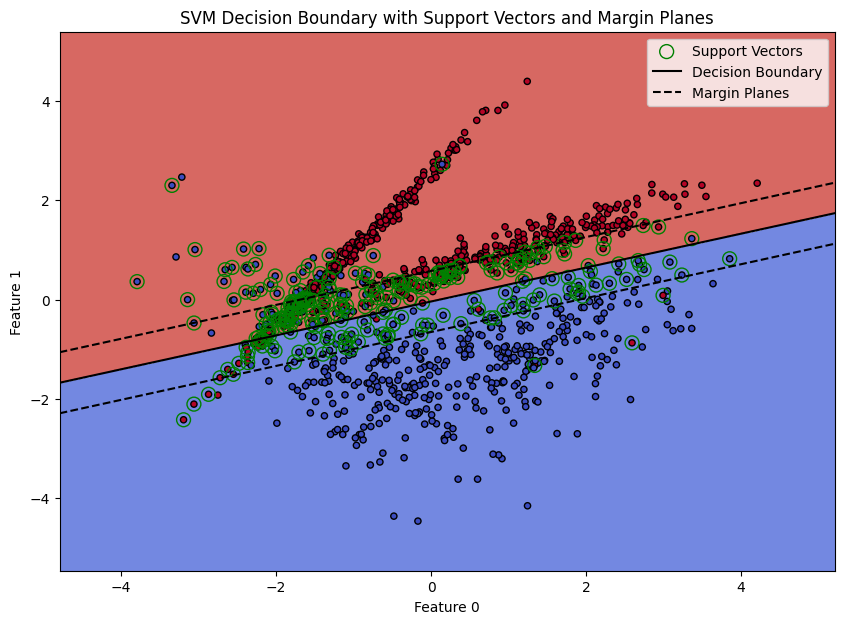

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Get min and max values for the features to define the plot boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a mesh grid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict class labels for each point on the mesh grid
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and margins
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

# Plot the support vectors
plt.scatter(svc.support_vectors_[:, 0],
            svc.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='green', label='Support Vectors')

# Plot the decision boundary and margin lines
w = svc.coef_[0]
a = -w[0] / w[1]
xx_line = np.linspace(x_min, x_max)
yy_line = a * xx_line - (svc.intercept_[0]) / w[1] # Decision Boundary

margin = 1 / np.sqrt(np.sum(w ** 2))
yy_down = yy_line - np.sqrt(1 + a ** 2) * margin # Lower Margin
yy_up = yy_line + np.sqrt(1 + a ** 2) * margin   # Upper Margin

plt.plot(xx_line, yy_line, 'k-', label='Decision Boundary')
plt.plot(xx_line, yy_down, 'k--', label='Margin Planes')
plt.plot(xx_line, yy_up, 'k--')

plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('SVM Decision Boundary with Support Vectors and Margin Planes')
plt.legend()
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()